In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\DELL\anaconda3\1\envs\py11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#only get data analysis jobs
df_da_us=df[(df['job_title_short'] =='Data Analyst') & (df['job_country']=='United States')].copy()


#drp nan values from the column for plotting
df_da_us=df_da_us.dropna(subset=['salary_year_avg'])

df_da_us['salary_year_avg'].sample(10)

500381     81641.0
412915     90000.0
160065     62500.0
744297     81682.0
549751     47500.0
27428     102500.0
448353     61353.0
418267     94000.0
442298     95000.0
746317    115000.0
Name: salary_year_avg, dtype: float64

<Axes: >

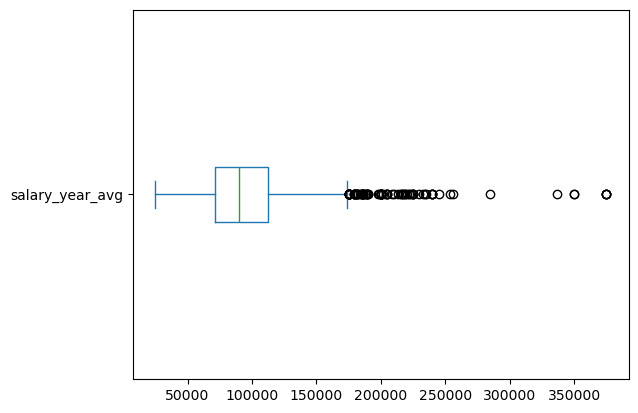

In [10]:
df_da_us['salary_year_avg'].plot(kind='box', vert=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x1f0d6d2d7f0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f0d6d2da90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f0d6d2d6a0>],
 'medians': [<matplotlib.lines.Line2D at 0x1f0d6d2dd30>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f0d6d2de80>],
 'means': []}

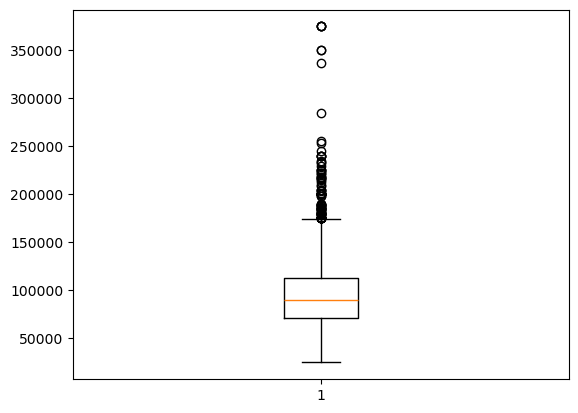

In [9]:
plt.boxplot(df_da_us['salary_year_avg'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_34172\3985630573.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


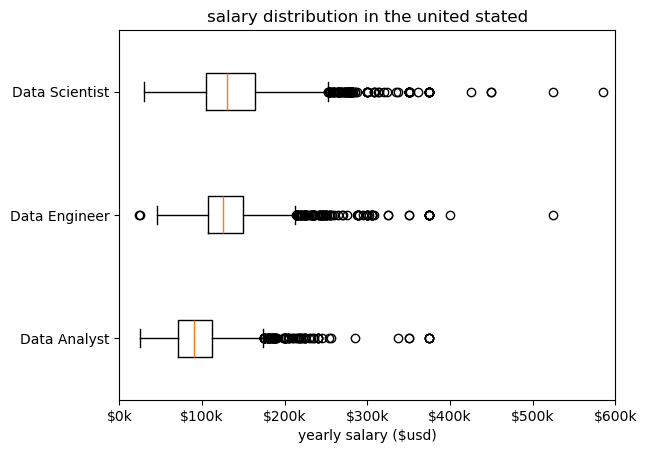

In [21]:
job_titles=['Data Analyst', 'Data Engineer', 'Data Scientist']

#filter the data to appropriate job titles
#only get data analyst jobs
df_us=df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].copy()

df_us= df_us.dropna(subset=['salary_year_avg'])

job_list= [df_us[df_us['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('salary distribution in the united stated')
plt.xlabel('yearly salary ($usd)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0,600000)
plt.show()

In [17]:
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64

In [14]:
df_us['salary_year_avg']

92        120000.0
100       228222.0
109        89000.0
116       114000.0
146       129500.0
            ...   
785563    136400.0
785624    139216.0
785641    150000.0
785648    221875.0
785692    157500.0
Name: salary_year_avg, Length: 11818, dtype: float64